In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30,nn.AvgPool2d,nn.MaxPool2d),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 80, 3, padding=1, groups=20),
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 80, 1),   # pointwise conv
    nn.BatchNorm2d(80),
    nn.PReLU(),

    nn.Conv2d(80, 60, 3, padding=1, groups=20),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60,nn.AvgPool2d,nn.MaxPool2d),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model42_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model42_0)
describe(model42_0)

MACs: 4.97 MMac, Params: 31.15 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model42_0.pt
Starting
Epoch 1/60: Train loss = 1.2046, Train accuracy = 0.5797, Test loss = 1.1831, Test accuracy = 0.5956
Epoch 2/60: Train loss = 0.8623, Train accuracy = 0.6975, Test loss = 0.8516, Test accuracy = 0.7046
Epoch 3/60: Train loss = 0.7721, Train accuracy = 0.7284, Test loss = 0.7638, Test accuracy = 0.7335
Epoch 4/60: Train loss = 0.6954, Train accuracy = 0.7579, Test loss = 0.7083, Test accuracy = 0.7606
Epoch 5/60: Train loss = 0.6665, Train accuracy = 0.7723, Test loss = 0.7069, Test accuracy = 0.7672
Epoch 6/60: Train loss = 0.6364, Train accuracy = 0.7768, Test loss = 0.6658, Test accuracy = 0.7761
Epoch 7/60: Train loss = 0.5495, Train accuracy = 0.8101, Test loss = 0.5939, Test accuracy = 0.7969
Epoch 8/60: Train loss = 0.5452, Train accuracy = 0.8106, Test loss = 0.5828, Test accuracy = 0.8063
Epoch 9/60: Train loss = 0.5679, Train accuracy = 0.8049, Test loss = 0.6060, Test accuracy = 0.8009
Epoch 10/60: Train loss = 0.552

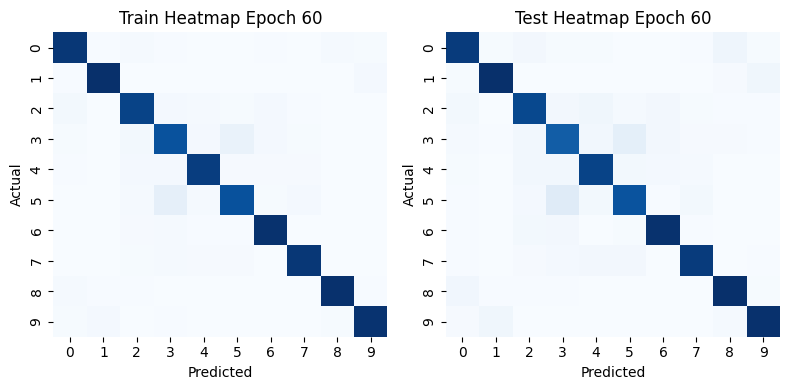

<Figure size 1200x600 with 0 Axes>

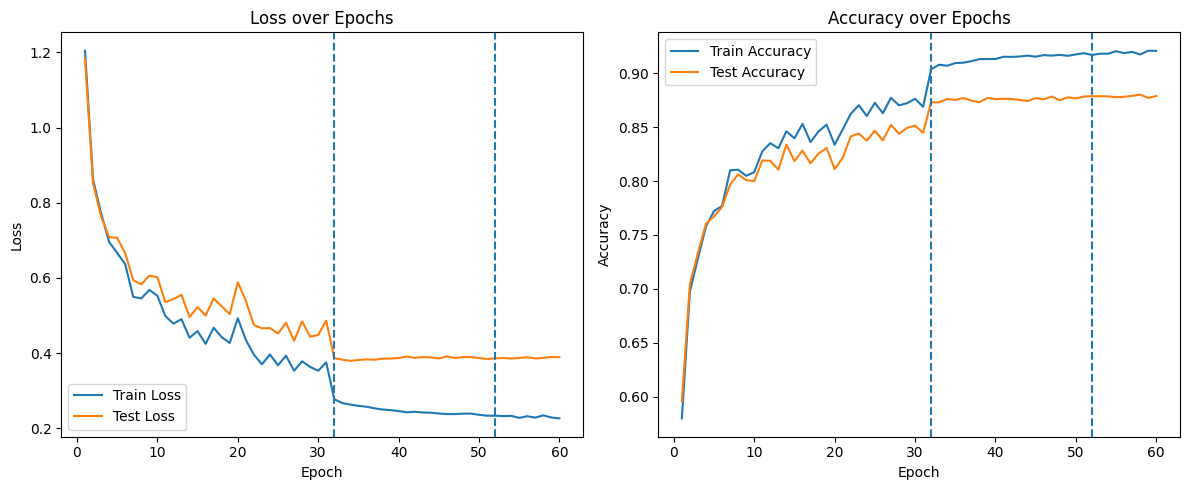

In [6]:
trainf32(model42_0,"model_weights/model42_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model42_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model42_1)
describe(model42_1)

MACs: 4.97 MMac, Params: 31.15 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model42_1.pt
Starting
Epoch 1/60: Train loss = 1.1489, Train accuracy = 0.6144, Test loss = 1.2462, Test accuracy = 0.6005
Epoch 2/60: Train loss = 0.8311, Train accuracy = 0.7096, Test loss = 0.8461, Test accuracy = 0.7127
Epoch 3/60: Train loss = 0.7449, Train accuracy = 0.7449, Test loss = 0.7315, Test accuracy = 0.7511
Epoch 4/60: Train loss = 0.6685, Train accuracy = 0.7673, Test loss = 0.6775, Test accuracy = 0.7686
Epoch 5/60: Train loss = 0.6084, Train accuracy = 0.7897, Test loss = 0.6273, Test accuracy = 0.7874
Epoch 6/60: Train loss = 0.5689, Train accuracy = 0.8023, Test loss = 0.5882, Test accuracy = 0.7977
Epoch 7/60: Train loss = 0.5441, Train accuracy = 0.8075, Test loss = 0.5817, Test accuracy = 0.8039
Epoch 8/60: Train loss = 0.5300, Train accuracy = 0.8167, Test loss = 0.5583, Test accuracy = 0.8149
Epoch 9/60: Train loss = 0.5032, Train accuracy = 0.8234, Test loss = 0.5263, Test accuracy = 0.8202
Epoch 10/60: Train loss = 0.506

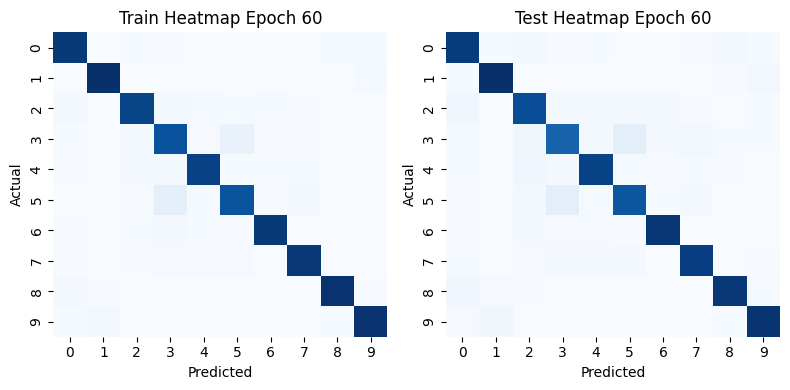

<Figure size 1200x600 with 0 Axes>

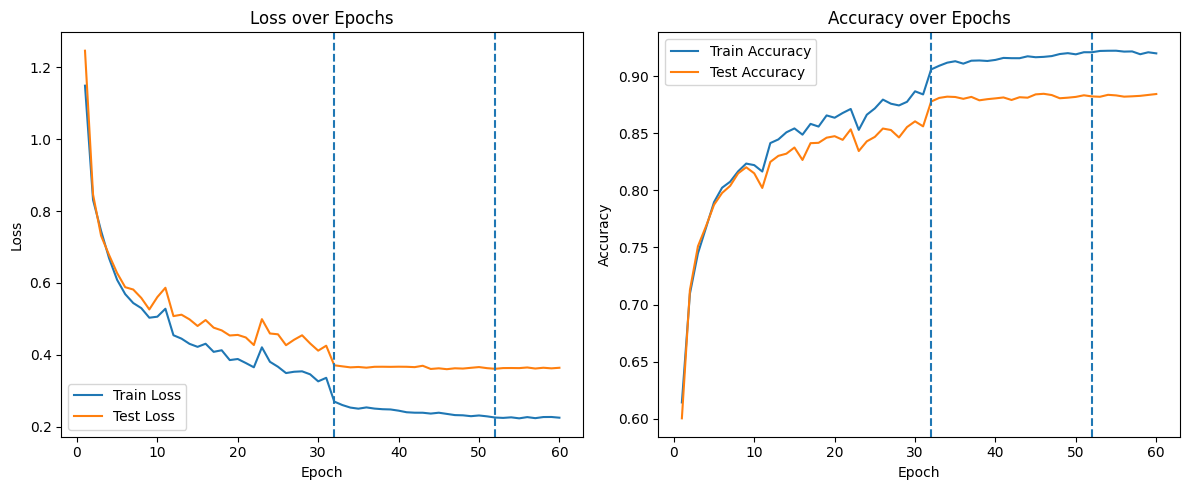

In [8]:
trainf32(model42_1,"model_weights/model42_1.pt",criterion,train_dataset,val_dataset, batch_size=64)